## Import Necessary Libaray

In [66]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import requests
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from xgboost import XGBRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
import joblib


In [67]:
#load data frame 
df=pd.read_csv('Utility_consumption.csv')
df.head()


,Datetime,Temperature,Humidity,WindSpeed,F1_132KV_PowerConsumption,F2_132KV_PowerConsumption,F3_132KV_PowerConsumption
0,01-01-2017 00:00,6.559,73.8,0.083,34055.69620,16128.87538,20240.96386
1,01-01-2017 00:10,6.414,74.5,0.083,29814.68354,19375.07599,20131.08434
2,01-01-2017 00:20,6.313,74.5,0.080,29128.10127,19006.68693,19668.43373
3,01-01-2017 00:30,6.121,75.0,0.083,28228.86076,18361.09422,18899.27711
4,01-01-2017 00:40,5.921,75.7,0.081,27335.69620,17872.34043,18442.40964


In [68]:
# convert Datetime column into Datetime data type for analysis
df['Datetime'] = pd.to_datetime(df['Datetime'], dayfirst=True, format='mixed')
df = df.sort_values('Datetime').reset_index(drop=True)

#### After Analysing  Temperature ,Humidity and windspeed column. windspeed value are too low and too high so drop that column and replaced with wehther api data of that time. And create new windspeed and cloudcover column in dataframe

In [69]:
df = df.drop(columns=['WindSpeed'])

In [70]:
start_date = df['Datetime'].min().strftime('%Y-%m-%d')  
end_date   =  (df['Datetime'].max() + pd.Timedelta(days=1)).strftime('%Y-%m-%d')

In [71]:
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 23.7957,
    "longitude": 86.4304,
    "start_date": start_date,
    "end_date": end_date,      # adjust to your data range
    "hourly": ["windspeed_10m", "cloudcover"]
}
r = requests.get(url, params=params)
data = r.json()

In [72]:
weather_api = pd.DataFrame({
    "Datetime":   pd.to_datetime(data["hourly"]["time"]),
    "WindSpeed":  data["hourly"]["windspeed_10m"],
    "CloudCover": data["hourly"]["cloudcover"]
})

# Resample hourly → 10 min ─────────────────────────
weather_api = weather_api.set_index("Datetime")
weather_api = weather_api.resample("10min").interpolate(method="linear")
weather_api = weather_api.reset_index()
print("Before trim:", weather_api.shape)   # (52555, 3)

# Trim extra rows beyond CSV end ────────────────────
weather_api = weather_api[weather_api['Datetime'] <= df['Datetime'].max()]
weather_api = weather_api.reset_index(drop=True)
print("After trim:", weather_api.shape)    # (52416, 3)

# ── Step 6: Merge ─────────────────────────────────────────────
df = df.merge(weather_api, on="Datetime", how="left")

Before trim: (52555, 3)
After trim: (52416, 3)


#### create  hoilday of dhanbad and merge with data frame with isholiday and holiday name.

In [73]:
holidays_2017 = {
    # Fixed date holidays (same every year)
    "2017-01-26": "Republic Day",
    "2017-08-15": "Independence Day",
    "2017-10-02": "Gandhi Jayanti",
    "2017-11-15": "Jharkhand Foundation Day",  # always Nov 15
    "2017-05-01": "Labour Day",                # always May 1
    "2017-12-25": "Christmas",                 # always Dec 25
    "2017-08-09":"World Tribal Day",
    "2017-04-14":"Good Friday",

    # Lunar calendar holidays (2017 specific dates)
    "2017-01-14": "Makar Sankranti",
    "2017-03-13": "Holi",
    "2017-03-28": "Hindu new year",     
    "2017-03-30": "Sarhul",          # Jharkhand tribal
    "2017-04-05":"Ram Navami",
    "2017-04-14": "Ambedkar Jayanti",
    "2017-06-26": "Eid ul Fitr",
    
    "2017-08-07":"Raksha Bandhan",
    "2017-08-14": "Janmashtami",
    "2017-08-25":"Ganesh Chaturthi",
    "2017-09-01": "Eid ul Adha/Bakrid",
    "2017-09-17": "Karma Puja",      # Jharkhand local
    "2017-09-30": "Dussehra",
    "2017-10-01":"Muharram",
    "2017-10-19": "Diwali",
    "2017-10-20": "Diwali (2nd day)",
    "2017-10-26": "Chhath Puja",     # Biggest festival Jharkhand
    "2017-10-27": "Chhath Puja",     # 2 days celebrated
    "2017-11-04":"Guru Nanak Jayanti"
}
# Build holiday dataframe
holiday_df = pd.DataFrame({
    "Date":         pd.to_datetime(list(holidays_2017.keys())).date,
    "is_holiday":   1,
    "holiday_name": list(holidays_2017.values())
})

# Merge on date only
df['Date'] = df['Datetime'].dt.date
df = df.merge(holiday_df, on='Date', how='left')
df['is_holiday']   = df['is_holiday'].fillna(0).astype(int)
df['holiday_name'] = df['holiday_name'].fillna('None')
df = df.drop(columns=['Date'])

#### combine F1_132KV_PowerConsumption,F2_132KV_PowerConsumption,F3_132KV_PowerConsumption to make Total_load and create block column for every 10 min 

In [74]:
df['Total_Load']  = (df['F1_132KV_PowerConsumption'] +
                     df['F2_132KV_PowerConsumption'] +
                     df['F3_132KV_PowerConsumption'])

df['Block']       = df['Datetime'].dt.hour * 6 + df['Datetime'].dt.minute // 10
df['Block_Label'] = df['Datetime'].dt.strftime('%H:%M')

In [75]:
df.head()

,Datetime,Temperature,Humidity,F1_132KV_PowerConsumption,F2_132KV_PowerConsumption,F3_132KV_PowerConsumption,WindSpeed,CloudCover,is_holiday,holiday_name,Total_Load,Block,Block_Label
0,2017-01-01 00:00:00,6.559,73.8,34055.69620,16128.87538,20240.96386,5.6,1.000000,0,None,70425.53544,0,00:00
1,2017-01-01 00:10:00,6.414,74.5,29814.68354,19375.07599,20131.08434,5.4,0.833333,0,None,69320.84387,1,00:10
2,2017-01-01 00:20:00,6.313,74.5,29128.10127,19006.68693,19668.43373,5.2,0.666667,0,None,67803.22193,2,00:20
3,2017-01-01 00:30:00,6.121,75.0,28228.86076,18361.09422,18899.27711,5.0,0.500000,0,None,65489.23209,3,00:30
4,2017-01-01 00:40:00,5.921,75.7,27335.69620,17872.34043,18442.40964,4.8,0.333333,0,None,63650.44627,4,00:40


In [ ]:
# statistical information about the data
df.describe()

,Datetime,Temperature,Humidity,F1_132KV_PowerConsumption,F2_132KV_PowerConsumption,F3_132KV_PowerConsumption,WindSpeed,CloudCover,is_holiday,Total_Load,Block
count,52416,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000
mean,2017-07-01 23:55:00,18.810024,68.259518,32344.970564,21042.509082,17835.406218,8.250293,44.057044,0.071429,71222.885864,71.500000
min,2017-01-01 00:00:00,3.247000,11.340000,13895.696200,8560.081466,5935.174070,0.000000,0.000000,0.000000,36785.039739,0.000000
25%,2017-04-01 23:57:30,14.410000,58.310000,26310.668692,16980.766032,13129.326630,5.450000,0.000000,0.000000,56499.074640,35.750000
50%,2017-07-01 23:55:00,18.780000,69.860000,32265.920340,20823.168405,16415.117470,7.633333,31.000000,0.000000,69788.790940,71.500000
75%,2017-09-30 23:52:30,22.890000,81.400000,37309.018185,24713.717520,21624.100420,10.400000,95.000000,0.000000,83749.172310,107.250000
max,2017-12-30 23:50:00,40.010000,94.800000,52204.395120,37408.860760,47598.326360,32.800000,100.000000,1.000000,134208.145950,143.000000
std,NaN,5.815476,15.551177,7130.562564,5201.465892,6622.165099,4.037349,42.192737,0.257542,17143.138964,41.568614


In [ ]:
#  Shape of dataframe
df.shape

(52416, 13)

In [ ]:
#check data type of column of each column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Datetime                   52416 non-null  datetime64[us]
 1   Temperature                52416 non-null  float64       
 2   Humidity                   52416 non-null  float64       
 3   F1_132KV_PowerConsumption  52416 non-null  float64       
 4   F2_132KV_PowerConsumption  52416 non-null  float64       
 5   F3_132KV_PowerConsumption  52416 non-null  float64       
 6   WindSpeed                  52416 non-null  float64       
 7   CloudCover                 52416 non-null  float64       
 8   is_holiday                 52416 non-null  int64         
 9   holiday_name               52416 non-null  str           
 10  Total_Load                 52416 non-null  float64       
 11  Block                      52416 non-null  int32         
 12  Block_Label    

In [11]:
# checking null present or not in dataframe
df.isnull().sum()

Datetime                     0
Temperature                  0
Humidity                     0
F1_132KV_PowerConsumption    0
F2_132KV_PowerConsumption    0
F3_132KV_PowerConsumption    0
WindSpeed                    0
CloudCover                   0
is_holiday                   0
holiday_name                 0
Total_Load                   0
Block                        0
Block_Label                  0
dtype: int64

## Exploratory Data Analysis


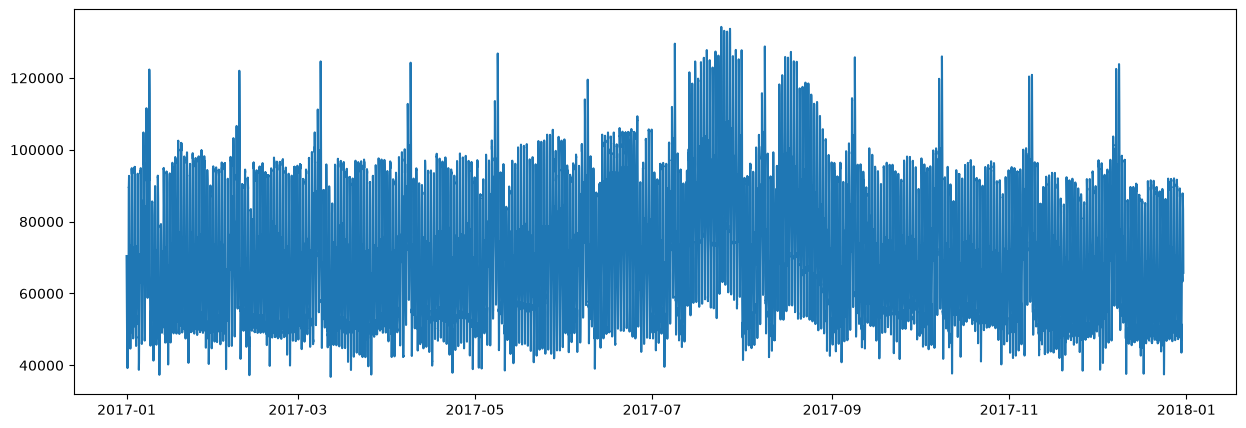

In [21]:
plt.figure(figsize=(15,5))
plt.plot(df["Datetime"], df["Total_Load"])

##### Observation: based on Graph daily load between 40000 to 130000 watt.

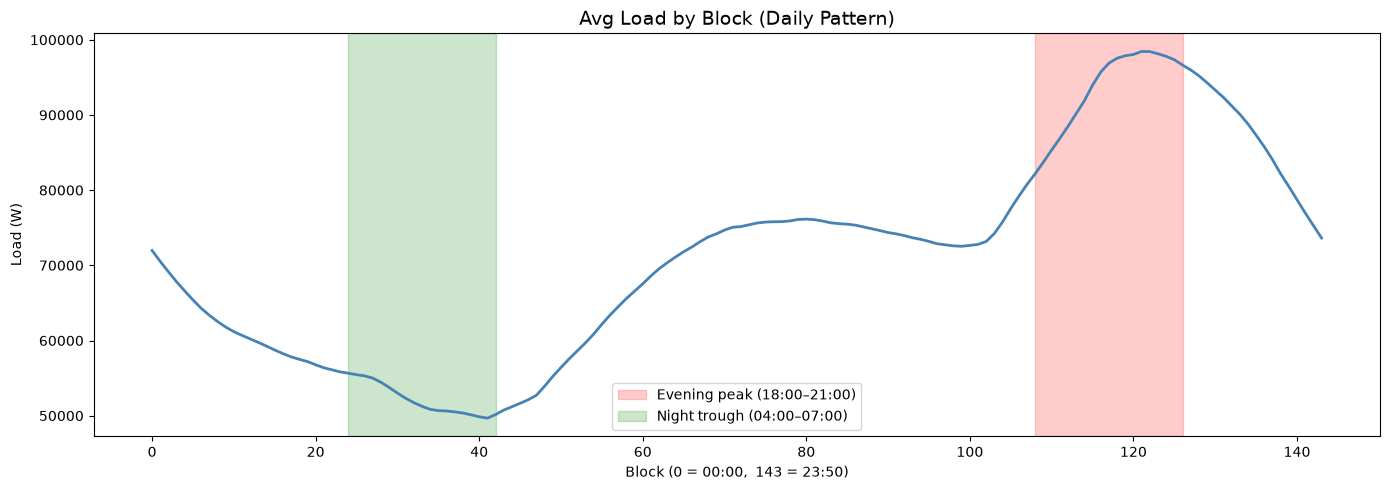

In [ ]:
block_avg = df.groupby('Block')['Total_Load'].mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(block_avg.index, block_avg.values, color='steelblue', linewidth=2)
ax.axvspan(108, 126, alpha=0.2, color='red',   label='Evening peak (18:00–21:00)')
ax.axvspan(24,   42, alpha=0.2, color='green', label='Night trough (04:00–07:00)')
ax.set_title('Avg Load by Block (Daily Pattern)', fontsize=14)
ax.set_xlabel('Block (0 = 00:00,  143 = 23:50)')
ax.set_ylabel('Load (W)')
ax.legend()
plt.tight_layout()
plt.show()

#### Observation: Based on this graph we can say that during Evening (between 6-9 pm) demand at peak around 95000 Watt. And during Night demand are low around 40000 Watt.

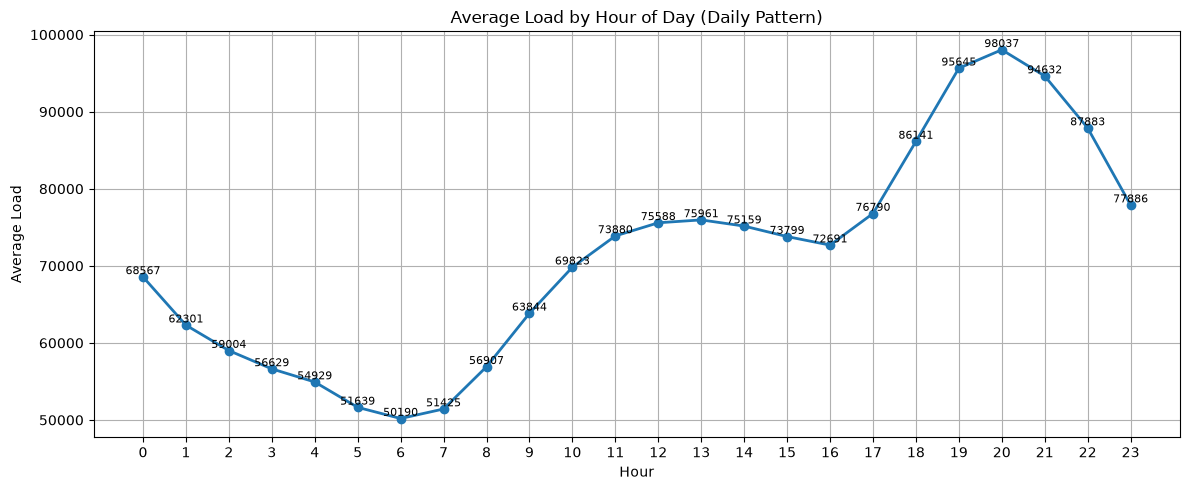

In [ ]:
# Average load for each hour of day
hourly_load = df.groupby(df['Datetime'].dt.hour)['Total_Load'].mean()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    hourly_load.index,
    hourly_load.values,
    marker='o',
    linewidth=2
)

for x, y in zip(hourly_load.index, hourly_load.values):
    ax.text(
        x,
        y,
        f'{y:.0f}',
        fontsize=8,
        ha='center',
        va='bottom'
    )

ax.set_title('Average Load by Hour of Day (Daily Pattern)')
ax.set_xlabel('Hour')
ax.set_ylabel('Average Load')
ax.set_xticks(range(24))
ax.grid(True)

plt.tight_layout()
plt.show()

#### Observation: Based on this graph it show the daily avgerage load comsumpation  and demand are low at 5-7 am and high at 6-8 pm. 

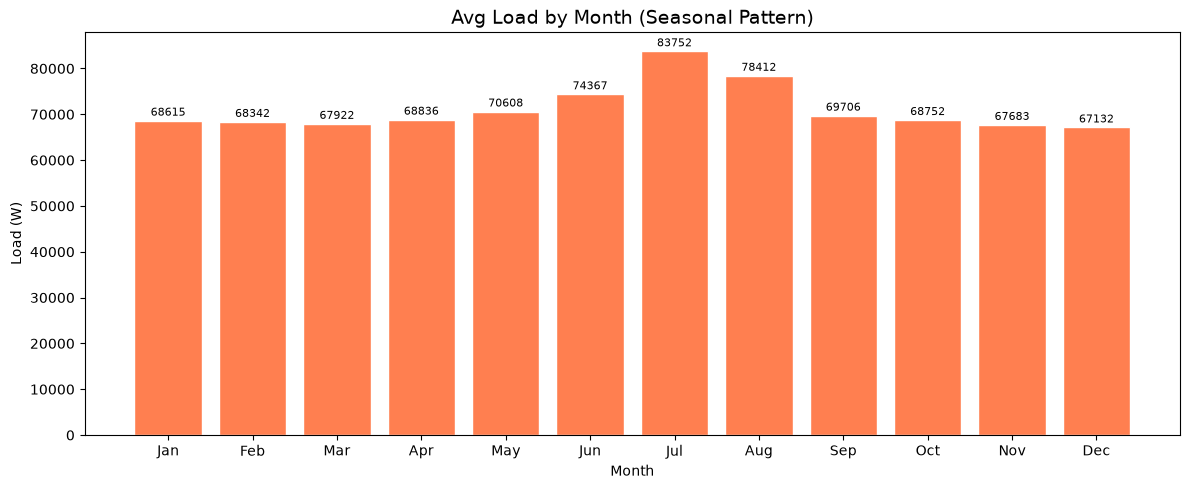

In [23]:
monthly_avg = df.groupby(df['Datetime'].dt.month)['Total_Load'].mean()
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(months, monthly_avg.values, color='coral', edgecolor='white')
ax.set_title('Avg Load by Month (Seasonal Pattern)', fontsize=14)
ax.set_ylabel('Load (W)')
ax.set_xlabel('Month')

# Add value labels on each bar
for bar, val in zip(bars, monthly_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 500,
            f'{val:.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

#### observation : This graph show the average load comsumpation by month . Demand are Incresing from April and Augest due to summer.

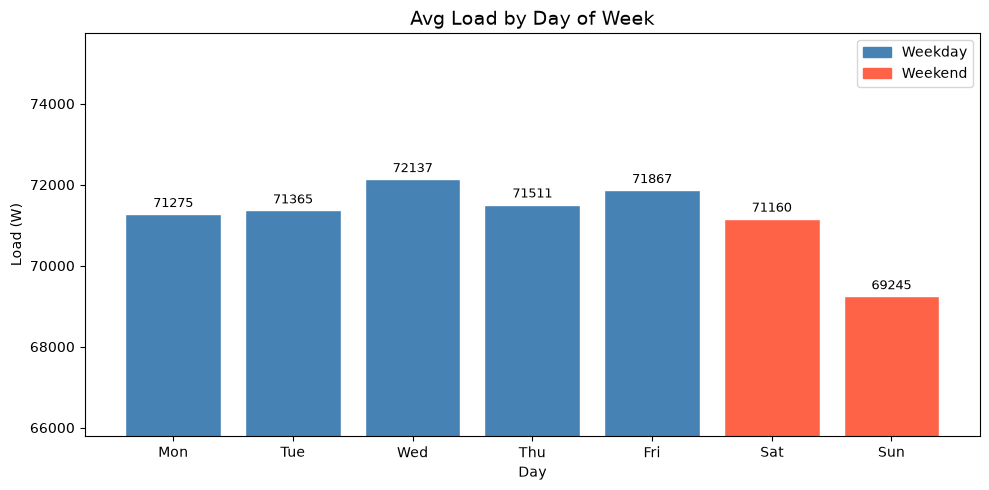

In [11]:
dow_avg = df.groupby(df['Datetime'].dt.dayofweek)['Total_Load'].mean()
days    = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
colors  = ['steelblue']*5 + ['tomato']*2   # weekdays blue, weekends red

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(days, dow_avg.values, color=colors, edgecolor='white')
ax.set_title('Avg Load by Day of Week', fontsize=14)
ax.set_ylabel('Load (W)')
ax.set_xlabel('Day')
ax.set_ylim(dow_avg.min() * 0.95, dow_avg.max() * 1.05)

# Add value labels
for bar, val in zip(bars, dow_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 100,
            f'{val:.0f}', ha='center', va='bottom', fontsize=9)

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='steelblue', label='Weekday'),
                   Patch(color='tomato',    label='Weekend')])
plt.tight_layout()
plt.show()


#### Observation: Load comsumpation are high during weekday and low at during weekend this is based on data.

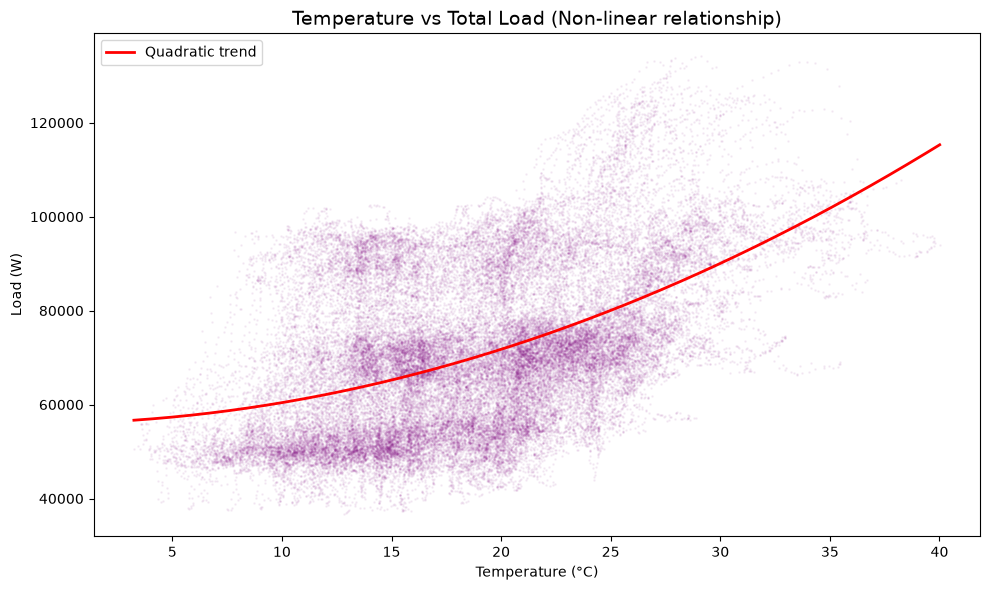

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df['Temperature'], df['Total_Load'],
                     alpha=0.05, color='purple', s=1)
# Add trend line
z = np.polyfit(df['Temperature'], df['Total_Load'], 2)  # degree 2 = quadratic
p = np.poly1d(z)
x_line = np.linspace(df['Temperature'].min(), df['Temperature'].max(), 300)
ax.plot(x_line, p(x_line), color='red', linewidth=2, label='Quadratic trend')
ax.set_title('Temperature vs Total Load (Non-linear relationship)', fontsize=14)
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Load (W)')
ax.legend()
plt.tight_layout()
plt.show()


#### Observation: This Graph show that as temperture is increasing Load comsumpation is also increase.

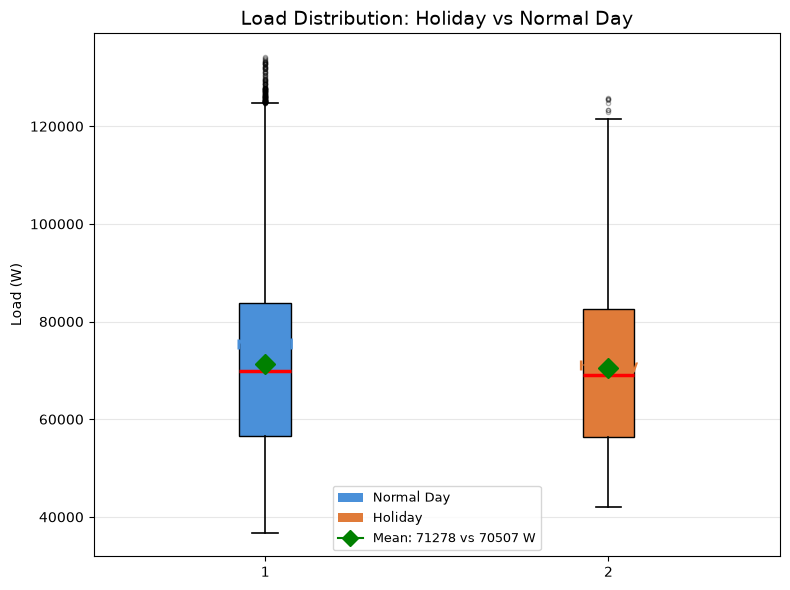

In [12]:
holiday_load    = df[df['is_holiday'] == 1]['Total_Load']
nonholiday_load = df[df['is_holiday'] == 0]['Total_Load']

fig, ax = plt.subplots(figsize=(8, 6))

bp = ax.boxplot(
    [nonholiday_load, holiday_load],
    label=['Normal Day', 'Holiday'],        # ← fix: labels not label
    patch_artist=True,
    boxprops=dict(color='black'),
    medianprops=dict(color='red', linewidth=2.5),
    whiskerprops=dict(color='black', linewidth=1.2),
    capprops=dict(color='black', linewidth=1.2),
    flierprops=dict(marker='o', markersize=3, alpha=0.3)
)

# ← Give each box a clearly different color
bp['boxes'][0].set_facecolor('#4A90D9')   # Normal Day — blue
bp['boxes'][1].set_facecolor('#E07B39')   # Holiday    — orange

ax.set_title('Load Distribution: Holiday vs Normal Day', fontsize=14)
ax.set_ylabel('Load (W)')

# Mean markers
ax.plot([1, 2],
        [nonholiday_load.mean(), holiday_load.mean()],
        'D', color='green', markersize=10, zorder=5,
        label=f'Mean — Normal: {nonholiday_load.mean():.0f} W  |  Holiday: {holiday_load.mean():.0f} W')

# Add text labels directly on boxes so it's obvious
ax.text(1, nonholiday_load.median() + 1000, 'Normal\nDay',
        ha='center', fontsize=10, fontweight='bold', color='#4A90D9')
ax.text(2, holiday_load.median() + 1000, 'Holiday',
        ha='center', fontsize=10, fontweight='bold', color='#E07B39')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#4A90D9', label='Normal Day'),
    Patch(facecolor='#E07B39', label='Holiday'),
    plt.Line2D([0], [0], marker='D', color='green',
               markersize=8, label=f'Mean: {nonholiday_load.mean():.0f} vs {holiday_load.mean():.0f} W')
], fontsize=9)

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### Observation: This show that During Normal day demand is high and holiday demand is Normal/low but their avergae demand is almost same.

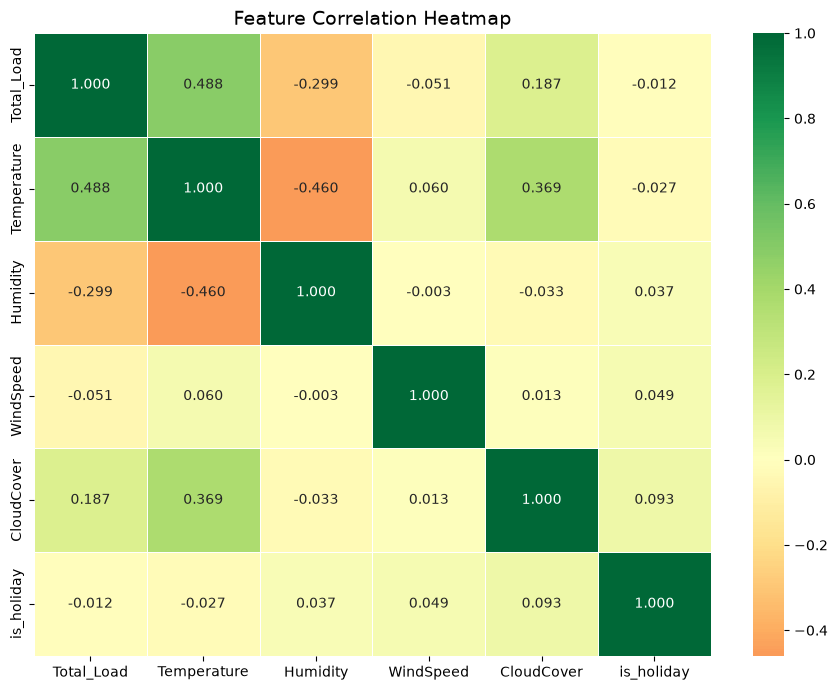

In [34]:
heatmap_cols = ['Total_Load','Temperature','Humidity',
                'WindSpeed','CloudCover','is_holiday']

fig, ax = plt.subplots(figsize=(9, 7))
corr_matrix = df[heatmap_cols].corr()
sns.heatmap(corr_matrix,
            annot=True, fmt='.3f',
            cmap='RdYlGn', center=0,
            linewidths=0.5,
            ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('plot8_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

#### observation: This matrix show that how total_load,temperature,humidity,windspeed,cloudsover,is_holiday are correlated. Temperature is high correlated and is_holiday is low correlated

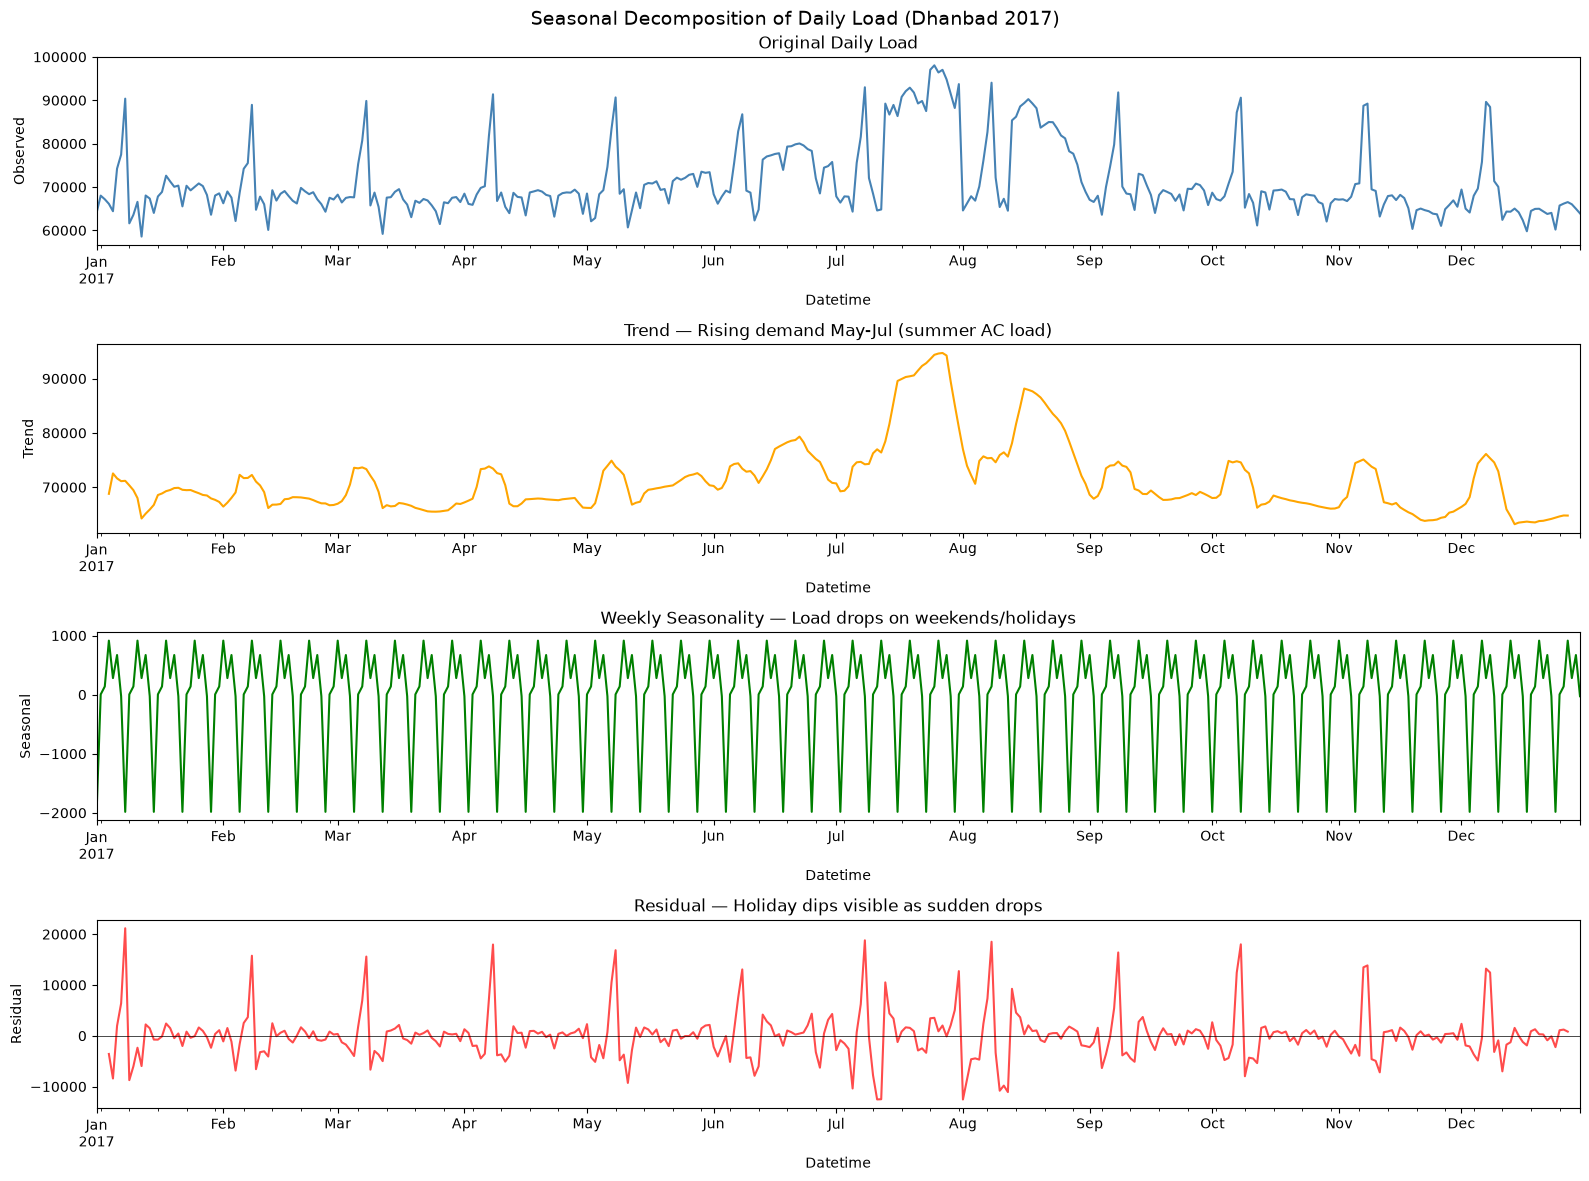

In [ ]:
daily = df.groupby(df['Datetime'].dt.date)['Total_Load'].mean()
daily.index = pd.to_datetime(daily.index)
daily = daily.asfreq('D')  # set daily frequency

# ── PART A: Seasonal Decomposition ────────────────────────────
# period=7 means weekly seasonality (7 days)
decomp = seasonal_decompose(daily, model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(16, 12))
fig.suptitle('Seasonal Decomposition of Daily Load (Dhanbad 2017)', fontsize=14)

decomp.observed.plot(ax=axes[0], color='steelblue')
axes[0].set_ylabel('Observed')
axes[0].set_title('Original Daily Load')

decomp.trend.plot(ax=axes[1], color='orange')
axes[1].set_ylabel('Trend')
axes[1].set_title('Trend — Rising demand May-Jul (summer AC load)')

decomp.seasonal.plot(ax=axes[2], color='green')
axes[2].set_ylabel('Seasonal')
axes[2].set_title('Weekly Seasonality — Load drops on weekends/holidays')

decomp.resid.plot(ax=axes[3], color='red', alpha=0.7)
axes[3].set_ylabel('Residual')
axes[3].set_title('Residual — Holiday dips visible as sudden drops')
axes[3].axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()



### Observation

#### 1. Observed
The observed daily load shows clear variations throughout the year, with demand generally ranging between **60,000 W and 100,000 W**.

##### Key Points:
- Load remains relatively stable during January–April.
- A noticeable increase in demand occurs from May to August.
- Peak demand reaches approximately **95,000–98,000 W** during late July and early August.
- After September, demand gradually declines and stabilizes during the winter months.

---

#### 2. Trend
The trend component represents the long-term movement of electricity demand.

##### Key Points:
- Demand steadily increases from May through July.
- Maximum trend values occur during July–August.
- After August, demand begins to decrease and returns to lower levels by October–December.

---

#### 3. Seasonal
The seasonal component exhibits a highly repetitive weekly pattern.

##### Key Points:
- The same pattern repeats every seven days.
- Significant negative seasonal effects occur periodically.
- Seasonal values range approximately from **−2000 W to +1000 W**.

---

#### 4. Residual
The residual component captures random fluctuations not explained by trend or seasonality.

##### Key Points:
- Most residual values remain close to zero.
- Several sharp positive and negative spikes are visible.
- Large residual deviations occur around major holidays and special events.

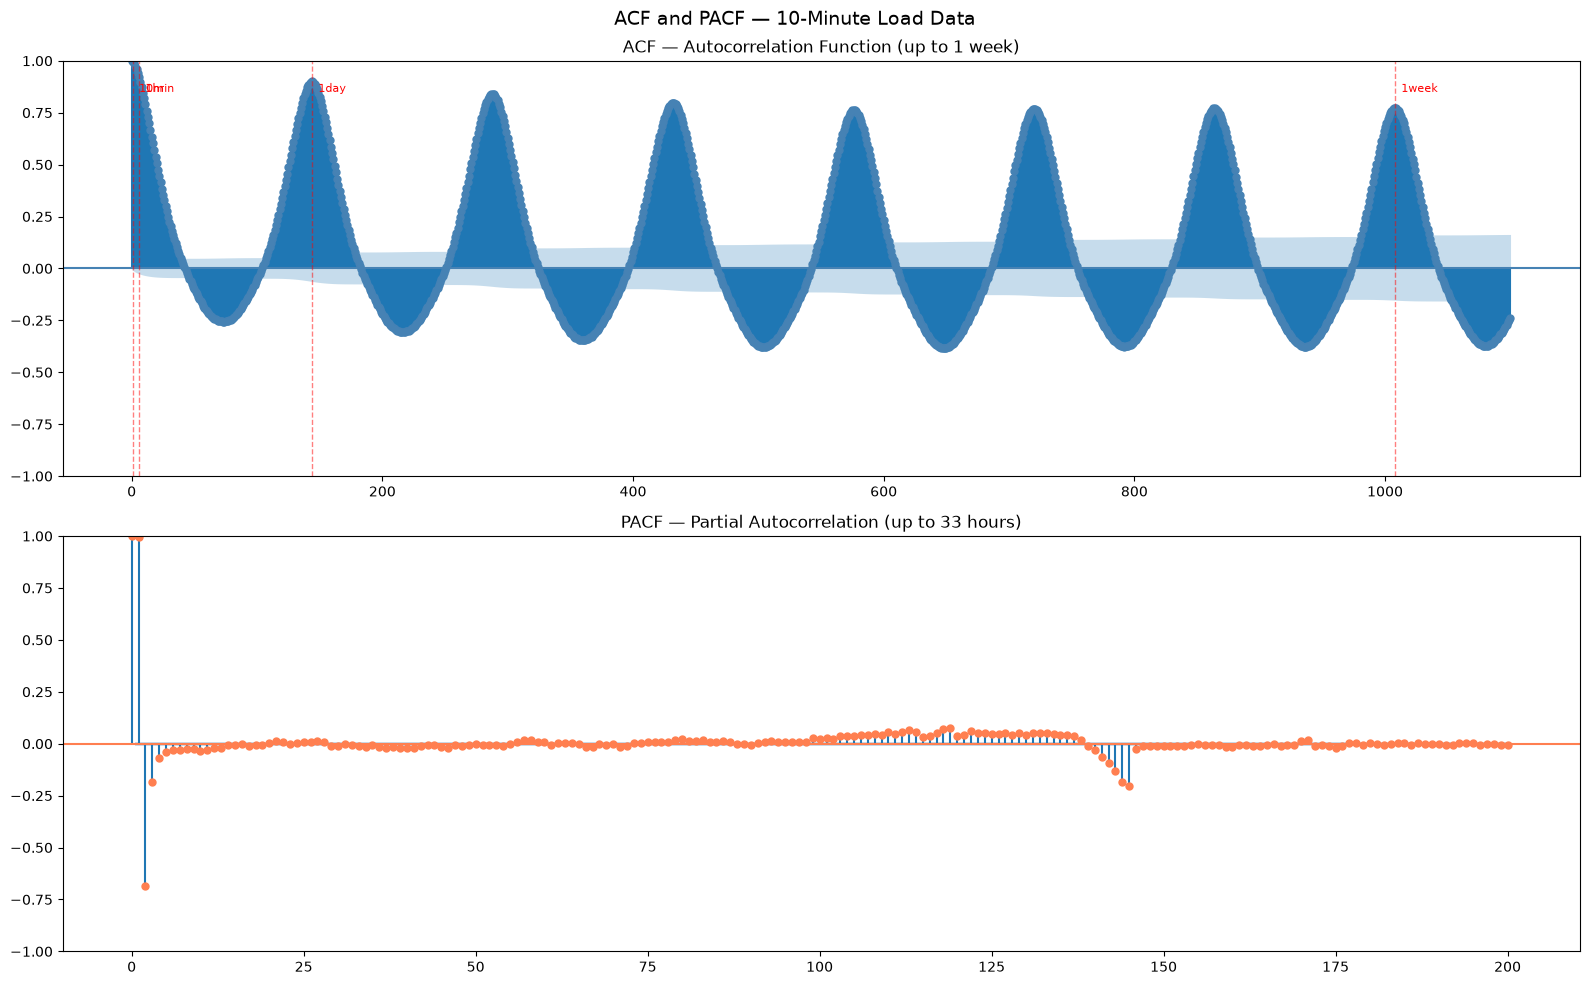

In [16]:
# ── PART B: ACF and PACF on 10-minute data ────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('ACF and PACF — 10-Minute Load Data', fontsize=14)

# ACF — shows all significant lags
plot_acf(df['Total_Load'],
         lags=1100,          # show up to 1 week (1008 lags)
         alpha=0.05,         # 95% confidence band
         ax=axes[0],
         color='steelblue',
         title='ACF — Autocorrelation Function (up to 1 week)')

# Mark key lags
for lag, label in [(1,'10min'), (6,'1hr'), (144,'1day'), (1008,'1week')]:
    axes[0].axvline(x=lag, color='red', linestyle='--', alpha=0.5, linewidth=1)
    axes[0].text(lag+5, 0.85, label, color='red', fontsize=8)

# PACF — shows direct lag relationships (no intermediary)
plot_pacf(df['Total_Load'],
          lags=200,           # first 200 lags (~33 hours)
          alpha=0.05,
          ax=axes[1],
          method='ywm',
          color='coral',
          title='PACF — Partial Autocorrelation (up to 33 hours)')

plt.tight_layout()
plt.show()

#### Observation: ACF shows repeating peaks every 144 lags = daily cycle Peaks at 144, 288, 432, 576, 720, 864, 1008 → weekly pattern
#### PACF shows direct effect only at lag 1, 2, 3 Negative trough between peaks (anticorrelated at lag 72)


## Feature Engineering

In [76]:
# ── Time features ─────────────────────────────────────────────
df['Hour']      = df['Datetime'].dt.hour
df['DayOfWeek'] = df['Datetime'].dt.dayofweek
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)
df['Month']     = df['Datetime'].dt.month
df['Quarter']   = df['Datetime'].dt.quarter
df['DayOfYear'] = df['Datetime'].dt.dayofyear

# ── Cyclical encoding ─────────────────────────────────────────
df['Hour_sin']   = np.sin(2 * np.pi * df['Hour']      / 24)
df['Hour_cos']   = np.cos(2 * np.pi * df['Hour']      / 24)
df['Block_sin']  = np.sin(2 * np.pi * df['Block']     / 144)
df['Block_cos']  = np.cos(2 * np.pi * df['Block']     / 144)
df['Month_sin']  = np.sin(2 * np.pi * df['Month']     / 12)
df['Month_cos']  = np.cos(2 * np.pi * df['Month']     / 12)
df['DOW_sin']    = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
df['DOW_cos']    = np.cos(2 * np.pi * df['DayOfWeek'] / 7)

# ── Lag features (justified by ACF plot) ─────────────────────
df['Load_lag_1']    = df['Total_Load'].shift(1)    # 10 min ago
df['Load_lag_3']    = df['Total_Load'].shift(3)    # 30 min ago
df['Load_lag_6']    = df['Total_Load'].shift(6)    # 1 hr ago
df['Load_lag_144']  = df['Total_Load'].shift(144)  # yesterday same time
df['Load_lag_288']  = df['Total_Load'].shift(288)  # 2 days ago
df['Load_lag_1008'] = df['Total_Load'].shift(1008) # 1 week ago

# ── Rolling features (justified by decomposition plot) ────────
df['roll_mean_6']   = df['Total_Load'].shift(1).rolling(6).mean()
df['roll_mean_12']  = df['Total_Load'].shift(1).rolling(12).mean()
df['roll_mean_144'] = df['Total_Load'].shift(1).rolling(144).mean()
df['roll_std_6']    = df['Total_Load'].shift(1).rolling(6).std()
df['roll_max_144']  = df['Total_Load'].shift(1).rolling(144).max()
df['roll_min_144']  = df['Total_Load'].shift(1).rolling(144).min()


### Feature Engineering

- **Time Features:** Capture calendar effects such as hour of the day, day of the week, month, and weekend patterns.

- **Cyclical Features:** Represent repeating daily, weekly, and monthly patterns using sine and cosine transformations.

- **Lag Features:** Capture temporal dependencies between current electricity demand and historical load values.

- **Rolling Features:** Summarize recent demand trends, variability, and volatility using moving statistics such as mean, standard deviation, minimum, and maximum values.


In [ ]:
# After freature engineering some null added so remove that row from data.
df.isnull().sum()

Datetime                        0
Temperature                     0
Humidity                        0
F1_132KV_PowerConsumption       0
F2_132KV_PowerConsumption       0
F3_132KV_PowerConsumption       0
WindSpeed                       0
CloudCover                      0
is_holiday                      0
holiday_name                    0
Total_Load                      0
Block                           0
Block_Label                     0
Hour                            0
DayOfWeek                       0
IsWeekend                       0
Month                           0
Quarter                         0
DayOfYear                       0
Hour_sin                        0
Hour_cos                        0
Block_sin                       0
Block_cos                       0
Month_sin                       0
Month_cos                       0
DOW_sin                         0
DOW_cos                         0
Load_lag_1                      1
Load_lag_3                      3
Load_lag_6    

In [77]:
df = df.dropna().reset_index(drop=True)

In [15]:
df.isnull().sum()

Datetime                     0
Temperature                  0
Humidity                     0
F1_132KV_PowerConsumption    0
F2_132KV_PowerConsumption    0
F3_132KV_PowerConsumption    0
WindSpeed                    0
CloudCover                   0
is_holiday                   0
holiday_name                 0
Total_Load                   0
Block                        0
Block_Label                  0
Hour                         0
DayOfWeek                    0
IsWeekend                    0
Month                        0
Quarter                      0
DayOfYear                    0
Hour_sin                     0
Hour_cos                     0
Block_sin                    0
Block_cos                    0
Month_sin                    0
Month_cos                    0
DOW_sin                      0
DOW_cos                      0
Load_lag_1                   0
Load_lag_3                   0
Load_lag_6                   0
Load_lag_144                 0
Load_lag_288                 0
Load_lag

In [16]:
df.shape

(51408, 39)

In [ ]:
# This are feature which are used for training the model
feature_cols = [
  
    'Block', 'Hour',
    'Hour_sin', 'Hour_cos',
    'Block_sin', 'Block_cos',

  
    'Month', 'Quarter',
    'Month_sin', 'Month_cos',

    
    'DayOfWeek', 'IsWeekend',
    'DOW_sin', 'DOW_cos',

   
    'Load_lag_1', 'Load_lag_3', 'Load_lag_6', 
    'Load_lag_144', 'Load_lag_288', 'Load_lag_1008',

    
    'roll_mean_6', 'roll_mean_12', 'roll_mean_144',
    'roll_std_6', 'roll_max_144', 'roll_min_144',

   
    'Temperature', 'Humidity', 'WindSpeed', 'CloudCover',

    
    'is_holiday'
]

## Train-Test split for model prediction

In [79]:
split_index = int(len(df) * 0.8)   # 80% train, 20% test

train = df.iloc[:split_index]       # past data
test  = df.iloc[split_index:]       # future data

print(f"Train: {len(train)} rows  |  {train['Datetime'].min().date()} → {train['Datetime'].max().date()}")
print(f"Test:  {len(test)} rows   |  {test['Datetime'].min().date()} → {test['Datetime'].max().date()}")

Train: 41126 rows  |  2017-01-08 → 2017-10-20
Test:  10282 rows   |  2017-10-20 → 2017-12-30


In [80]:
X_train = train[feature_cols]
y_train = train['Total_Load']

X_test  = test[feature_cols]
y_test  = test['Total_Load']

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")


X_train shape: (41126, 31)
X_test shape:  (10282, 31)


##### model configuration for training the model 

In [30]:
model = XGBRegressor(
    n_estimators      = 1000,   # number of trees
                                # high value + early stopping = safe
    learning_rate     = 0.05,   # small = learns slowly but better
                                # justified: large dataset (51k rows)
    max_depth         = 6,      # tree depth
                                # justified: 32 features, moderate complexity
    subsample         = 0.8,    # use 80% rows per tree
                                # prevents overfitting
    colsample_bytree  = 0.8,    # use 80% features per tree
                                # prevents overfitting
    min_child_weight  = 10,     # min samples in leaf node
                                # justified: 51k rows, 10 is safe floor
    reg_alpha         = 0.1,    # L1 regularization
    reg_lambda        = 1.0,    # L2 regularization
    random_state      = 42,
    n_jobs            = -1,     # use all CPU cores
    verbosity         = 1
)

In [31]:
model.fit(
    X_train, y_train,
    eval_set              = [(X_train, y_train), (X_test, y_test)],
    verbose               = 100   # print every 100 trees
)

[0]	validation_0-rmse:16552.05349	validation_1-rmse:15450.31829
[100]	validation_0-rmse:706.16801	validation_1-rmse:775.97230
[200]	validation_0-rmse:570.24483	validation_1-rmse:732.02231
[300]	validation_0-rmse:525.44944	validation_1-rmse:715.55274
[400]	validation_0-rmse:495.43019	validation_1-rmse:708.45354
[500]	validation_0-rmse:472.29646	validation_1-rmse:707.64566
[600]	validation_0-rmse:455.36382	validation_1-rmse:703.29914
[700]	validation_0-rmse:440.31576	validation_1-rmse:702.76085
[800]	validation_0-rmse:427.25871	validation_1-rmse:701.72976
[900]	validation_0-rmse:415.21482	validation_1-rmse:701.30024
[999]	validation_0-rmse:403.79173	validation_1-rmse:699.94383


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [ ]:
# ── Predictions ───────────────────────────────────────────────
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)      
rmse = np.sqrt(mse)                             
r2   = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MAE  : {mae:.2f} W")
print(f"MSE  : {mse:.2f} W²")
print(f"RMSE : {rmse:.2f} W")     
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%")


MAE  : 396.73 W
MSE  : 489921.39 W²
RMSE : 699.94 W
R²   : 0.9980
MAPE : 0.61%


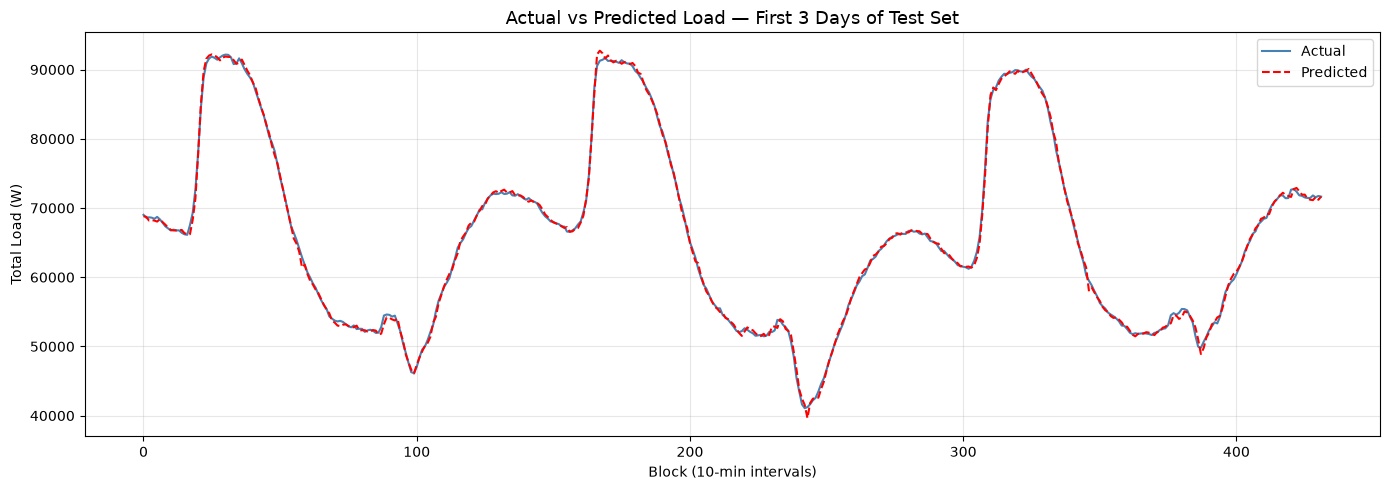

In [34]:
import matplotlib.pyplot as plt

# Actual vs Predicted — first 3 days of test set
fig, ax = plt.subplots(figsize=(14, 5))

n = 144 * 3   # 3 days = 432 blocks
ax.plot(y_test.values[:n],  label='Actual',    color='steelblue', linewidth=1.5)
ax.plot(y_pred[:n],         label='Predicted', color='red',
        linewidth=1.5, linestyle='--')

ax.set_title('Actual vs Predicted Load — First 3 Days of Test Set', fontsize=13)
ax.set_xlabel('Block (10-min intervals)')
ax.set_ylabel('Total Load (W)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
# Save model
joblib.dump(model, 'xgboost_model.pkl')

# Save feature column list — needed by API
import json
with open('feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

# Save last 1008 rows of history — needed for lag at prediction time
df.tail(1008)[['Datetime', 'Total_Load']].to_csv('history.csv', index=False)

print(" xgboost_model.pkl  — trained model")
print(" feature_cols.json  — feature list for API")
print(" history.csv        — last 1 week for lag calculation")

 xgboost_model.pkl  — trained model
 feature_cols.json  — feature list for API
 history.csv        — last 1 week for lag calculation


In [ ]:
train_pred = model.predict(X_train)
print("Train R2 Score:", r2_score(y_train, train_pred))

Train R2: 0.9994624074623274


In [ ]:
# This are feature are used for during training and this important for training as well as prediction
print(model.get_booster().feature_names)

['Block', 'Hour', 'Hour_sin', 'Hour_cos', 'Block_sin', 'Block_cos', 'Month', 'Quarter', 'Month_sin', 'Month_cos', 'DayOfWeek', 'IsWeekend', 'DOW_sin', 'DOW_cos', 'Load_lag_1', 'Load_lag_3', 'Load_lag_6', 'Load_lag_144', 'Load_lag_288', 'Load_lag_1008', 'roll_mean_6', 'roll_mean_12', 'roll_mean_144', 'roll_std_6', 'roll_max_144', 'roll_min_144', 'Temperature', 'Humidity', 'WindSpeed', 'CloudCover', 'is_holiday']


In [59]:


# Last timestamp
last_time = df['Datetime'].iloc[-1]
next_time = pd.Timestamp.now().ceil('10min')
# Create feature row
new_row = {}

# Time features
new_row['Block'] = next_time.hour * 6 + next_time.minute // 10
new_row['Hour'] = next_time.hour
new_row['DayOfWeek'] = next_time.dayofweek
new_row['IsWeekend'] = int(next_time.dayofweek >= 5)
new_row['Month'] = next_time.month
new_row['Quarter'] = (next_time.month - 1) // 3 + 1

# Cyclical features
new_row['Hour_sin'] = np.sin(2 * np.pi * new_row['Hour'] / 24)
new_row['Hour_cos'] = np.cos(2 * np.pi * new_row['Hour'] / 24)

new_row['Block_sin'] = np.sin(2 * np.pi * new_row['Block'] / 144)
new_row['Block_cos'] = np.cos(2 * np.pi * new_row['Block'] / 144)

new_row['Month_sin'] = np.sin(2 * np.pi * new_row['Month'] / 12)
new_row['Month_cos'] = np.cos(2 * np.pi * new_row['Month'] / 12)

new_row['DOW_sin'] = np.sin(2 * np.pi * new_row['DayOfWeek'] / 7)
new_row['DOW_cos'] = np.cos(2 * np.pi * new_row['DayOfWeek'] / 7)

# Lag features
new_row['Load_lag_1'] = df['Total_Load'].iloc[-1]
new_row['Load_lag_3'] = df['Total_Load'].iloc[-3]
new_row['Load_lag_6'] = df['Total_Load'].iloc[-6]
new_row['Load_lag_144'] = df['Total_Load'].iloc[-144]
new_row['Load_lag_288'] = df['Total_Load'].iloc[-288]
new_row['Load_lag_1008'] = df['Total_Load'].iloc[-1008]

# Rolling features
new_row['roll_mean_6'] = df['Total_Load'].tail(6).mean()
new_row['roll_mean_12'] = df['Total_Load'].tail(12).mean()
new_row['roll_mean_144'] = df['Total_Load'].tail(144).mean()

new_row['roll_std_6'] = df['Total_Load'].tail(6).std()
new_row['roll_max_144'] = df['Total_Load'].tail(144).max()
new_row['roll_min_144'] = df['Total_Load'].tail(144).min()

# Weather features
# Replace these with actual forecast values or latest available values
new_row['Temperature'] = 34
new_row['Humidity'] = 40
new_row['WindSpeed'] = 15
new_row['CloudCover'] = 9

# Holiday feature
new_row['is_holiday'] = 0

# Create dataframe
X_new = pd.DataFrame([new_row])

# Ensure same columns/order as training
X_new = X_new[feature_cols]

# Predict
prediction = model.predict(X_new)[0]

print(f" {next_time} for  Next 10-minute forecast: {prediction:.2f}")

 2026-06-15 20:10:00 for  Next 10-minute forecast: 64678.86
